# Education Trap Multi-Source Panel Dataset (9 Datasets, 1985–2023)

This notebook demonstrates the **Education Trap** dataset — a multi-source panel corpus of 51,594 examples
built from 9 authoritative data sources covering democracy, inequality, education, and economic indicators
for 181+ countries from 1985 to 2023.

Each example follows the `exp_sel_data_out` schema:
- **input**: JSON string of identifying/contextual features (country, year, indicators)
- **output**: string representation of the primary target variable

The 9 source datasets are:
1. **V-Dem V16** — democracy sub-indices + regime classification (4 classes)
2. **SWIID 9.2** — standardized disposable Gini inequality
3. **OWID/UNDP HDR** — mean years of schooling
4. **ILO SDG 1.3.1** — social protection coverage (%)
5. **Dreher 2006** — IMF program binary dummies
6. **WB WDI GDP per capita PPP** — constant 2017 int$
7. **WB WDI Gross tertiary enrollment** — gross enrollment rate (%)
8. **WB WDI GDP growth** — annual %
9. **WB WDI Labour force participation** — total (%)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — not pre-installed on Colab, always install
_pip('loguru>=0.7')

# Core packages — pre-installed on Colab, install locally only to match Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from loguru import logger

logger.remove()
GREEN, CYAN, END = "\033[92m", "\033[96m", "\033[0m"
fmt = f"{GREEN}{{time:HH:mm:ss}}{END}|{{level:<7}}|{CYAN}{{function}}{END}| {{message}}"
logger.add(sys.stdout, level="INFO", format=fmt)

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-395f4e-education-inequality-and-democratic-eros/main/round-2/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
logger.info(f"Loaded {len(data['datasets'])} datasets, "
            f"{sum(len(d['examples']) for d in data['datasets'])} total examples")

10:51:12|INFO   |<module>| Loaded 9 datasets, 27 total examples


## Config

Tunable parameters for the demo. Start at minimum values; scale up for a full run.

In [5]:
# --- Config (set to minimum for demo; scale up for full run) ---

# How many examples per dataset to inspect in detail
N_EXAMPLES_SHOW = 3          # original: all (3 in mini, 3000+ in full)

# Year range filter (original script uses 1985–2023)
YEAR_MIN = 1985              # original: 1985
YEAR_MAX = 2023              # original: 2023

## Dataset Overview

Print the names of all 9 source datasets and how many examples each contributed.

In [6]:
datasets = data["datasets"]

print(f"Total datasets: {len(datasets)}")
print(f"Total examples: {sum(len(d['examples']) for d in datasets)}")
print()
print(f"{'#':<4} {'Dataset':<55} {'Examples':>8}")
print("-" * 70)
for i, ds in enumerate(datasets, 1):
    print(f"{i:<4} {ds['dataset']:<55} {len(ds['examples']):>8}")

Total datasets: 9
Total examples: 27

#    Dataset                                                 Examples
----------------------------------------------------------------------
1    V-Dem V16 Democracy Sub-Indices (post-1985)                    3
2    SWIID 9.2 Standardized Gini Inequality                         3
3    UNDP HDR Mean Years of Schooling (OWID)                        3
4    ILO SDG 1.3.1 Social Protection Coverage                       3
5    Dreher 2006 IMF Program Binary Dummies                         3
6    WB WDI: GDP per capita PPP (constant 2017 int$)                3
7    WB WDI: Gross tertiary school enrollment (%)                   3
8    WB WDI: GDP growth (annual %)                                  3
9    WB WDI: Labour force participation rate (%)                    3


## Example Input/Output Structure

Each example has an `input` (JSON string of contextual features) and an `output` (string of the target variable).
Here we inspect the first `N_EXAMPLES_SHOW` examples from each dataset.

In [7]:
for ds in datasets:
    name = ds["dataset"]
    examples = ds["examples"][:N_EXAMPLES_SHOW]
    print(f"\n{'='*70}")
    print(f"Dataset: {name}")
    print(f"{'='*70}")
    for ex in examples:
        inp = json.loads(ex["input"])
        print(f"  input  : {inp}")
        print(f"  output : {ex['output']}")
        task = ex.get("metadata_task_type", "?")
        target = ex.get("metadata_target", "?")
        print(f"  task   : {task}  |  target: {target}")


Dataset: V-Dem V16 Democracy Sub-Indices (post-1985)
  input  : {'iso3': 'MEX', 'country': 'Mexico', 'year': 1985, 'v2x_libdem': '0.142', 'v2x_polyarchy': '0.32', 'v2juhcind': '-1.23', 'v2cseeorgs': '0.239', 'v2xcs_ccsi': '0.408', 'v2x_corr': '0.772', 'v2csreprss': '-0.655', 'v2csprtcpt': '-0.609'}
  output : 1 (Electoral Autocracy)
  task   : classification  |  target: v2x_regime
  input  : {'iso3': 'MEX', 'country': 'Mexico', 'year': 1986, 'v2x_libdem': '0.143', 'v2x_polyarchy': '0.322', 'v2juhcind': '-1.23', 'v2cseeorgs': '0.239', 'v2xcs_ccsi': '0.408', 'v2x_corr': '0.772', 'v2csreprss': '-0.655', 'v2csprtcpt': '-0.609'}
  output : 1 (Electoral Autocracy)
  task   : classification  |  target: v2x_regime
  input  : {'iso3': 'MEX', 'country': 'Mexico', 'year': 1987, 'v2x_libdem': '0.145', 'v2x_polyarchy': '0.327', 'v2juhcind': '-1.23', 'v2cseeorgs': '0.239', 'v2xcs_ccsi': '0.408', 'v2x_corr': '0.772', 'v2csreprss': '-0.655', 'v2csprtcpt': '-0.609'}
  output : 1 (Electoral Autocracy)


## Corpus Statistics

Build a flat DataFrame from all examples with metadata, then summarize task type distribution,
year coverage, and target variable ranges.

In [8]:
rows = []
for ds in datasets:
    for ex in ds["examples"]:
        row = {
            "dataset": ds["dataset"],
            "output": ex["output"],
            "task_type": ex.get("metadata_task_type", "unknown"),
            "target": ex.get("metadata_target", "unknown"),
            "year": ex.get("metadata_year"),
        }
        rows.append(row)

df = pd.DataFrame(rows)

# Apply year filter (mirrors YEAR_MIN/YEAR_MAX from original script)
df = df[df["year"].between(YEAR_MIN, YEAR_MAX)]

print("Task type distribution:")
print(df["task_type"].value_counts().to_string())
print(f"\nYear range in this demo: {df['year'].min()} – {df['year'].max()}")
print(f"\nExamples per target variable:")
print(df.groupby("target").size().sort_values(ascending=False).to_string())

Task type distribution:
task_type
regression        21
classification     6

Year range in this demo: 1985 – 2021

Examples per target variable:
target
gdp_growth_pct                    3
gdp_pc_ppp_2017usd                3
gini_disp                         3
gross_tertiary_enrolment_pct      3
imf_program_active                3
labour_force_participation_pct    3
mean_years_schooling              3
social_protection_coverage_pct    3
v2x_regime                        3


## Visualization

Two panels:
- **Left**: Example count per source dataset (bar chart)
- **Right**: Task type breakdown (pie chart — regression vs classification)

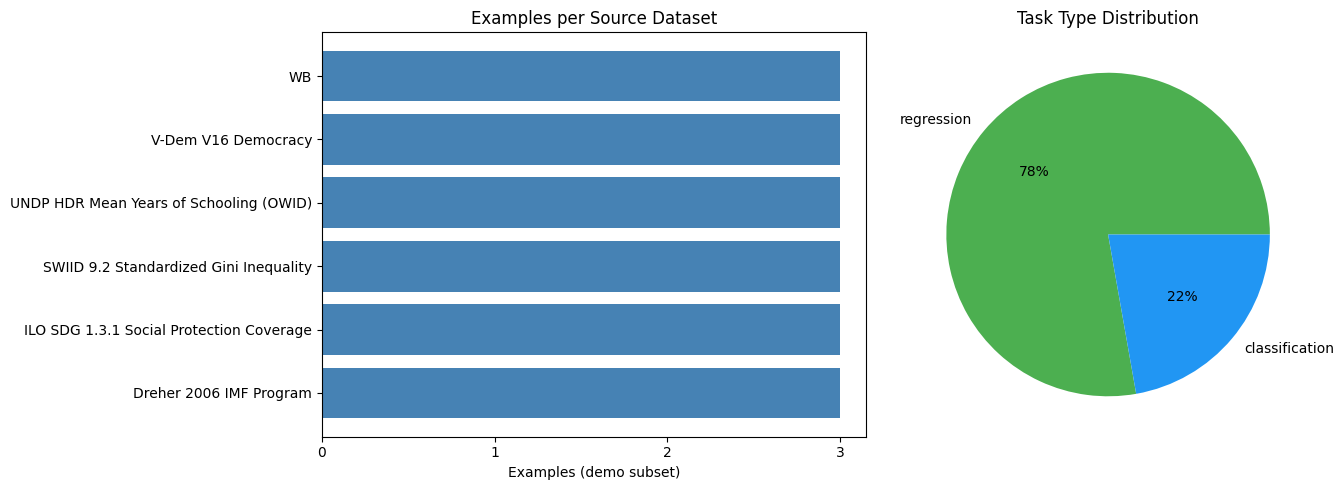

Saved dataset_overview.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: examples per dataset
ds_counts = df.groupby("dataset").size().sort_values(ascending=True)
short_names = [n.split(":")[0].replace("WB WDI", "WB").replace(" (post-1985)", "")
               .replace(" Sub-Indices", "").replace(" Binary Dummies", "")
               for n in ds_counts.index]
axes[0].barh(short_names, ds_counts.values, color="steelblue")
axes[0].set_xlabel("Examples (demo subset)")
axes[0].set_title("Examples per Source Dataset")
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Right: task type pie
task_counts = df["task_type"].value_counts()
axes[1].pie(task_counts.values, labels=task_counts.index, autopct="%1.0f%%",
            colors=["#4CAF50", "#2196F3", "#FF9800"][:len(task_counts)])
axes[1].set_title("Task Type Distribution")

plt.tight_layout()
plt.savefig("dataset_overview.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved dataset_overview.png")